<div style="background: linear-gradient(135deg, #1a237e 0%, #283593 40%, #303f9f 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">СӨЖ 19</h1>

  <p style="color:#e8eaf6; font-size:1em; margin:0;">Fine-tuning · Классификация · NER · Қысқарту · Аударма · Сұрақ-Жауап</p>
</div>

## Кіріспе

Бұл дəптер заманауи NLP-дің алты негізгі міндетін бір жерде қамтиды. Əр міндет минималды, бірақ жұмыс жасайтын түрде іске асырылады. Мақсат — нəтижені тез байқап, барлық тапсырмалармен жылдам танысу.

Барлық алты тапсырма `Hugging Face Transformers` кітапханасының `pipeline()` интерфейсімен жұмыс жасайды. `pipeline()` — алдын ала үйретілген моделді бірнеше жолда пайдалануға мүмкіндік беретін жоғары деңгейлі API.

Кейін əр тапсырма өзінің бөлек зертханасында (1–4) тереңірек зерттеледі.

## Оқу Мақсаттары

- `pipeline()` арқылы 6 NLP тапсырмасын іске асыра аласыз
- Fine-tuning, NER, Classification, Summarization, Translation, QA тапсырмаларының айырмасын түсіндіре аласыз
- Əр тапсырманың шығыс форматын (label, span, summary, translation) ажырата аласыз
- Трансформер-негізді NLP кезеңдерін жалпы схемада бейнелей аласыз



## 1-бөлім: Кітапханаларды Импорттау

In [22]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

# Hugging Face Transformers
try:
    from transformers import pipeline as hf_pipeline
    HF_AVAILABLE = True
    print("Transformers кітапханасы табылды.")
except ImportError:
    HF_AVAILABLE = False
    print("Transformers жоқ. Орнату: pip install transformers torch")
    print("Симуляция режімі іске қосылады.")

Transformers кітапханасы табылды.


In [23]:
# ============================================================
### TODO ###
# Transformers нұсқасын шығарыңыз.
# HF_AVAILABLE True болса: import transformers; print(transformers.__version__)
# ============================================================
if HF_AVAILABLE:
    import transformers
    print("Transformers нұсқасы:", transformers.__version__)
else:
    print("Симуляция режімі — нәтижелер алдын ала белгіленген.")

Transformers нұсқасы: 5.12.0


## 2-бөлім: Заманауи NLP Тапсырмалары — Жалпы Схема

Трансформер-негізді NLP pipeline əдетте мынадай кезеңдерден тұрады:

```
Кіріс мəтін → Токенизация → Алдын ала үйретілген BERT/GPT → Fine-tuning → Тапсырма шығысы
```

Тапсырма түріне байланысты шығыс форматы əртүрлі:

| Тапсырма | Кіріс | Шығыс |
|---|---|---|
| **Классификация** | Мəтін | Тап белгісі + ықтималдық |
| **NER** | Мəтін | Токен → {нысан: адам/орын/ұйым} |
| **Қысқарту** | Ұзын мəтін | Қысқа мəтін |
| **Аударма** | Бір тілдегі мəтін | Екінші тілдегі мəтін |
| **Сұрақ-жауап** | Контекст + Сұрақ | Жауап тіркесі (span) |
| **Fine-tuning** | Мəтін + Тап | Бейімделген модель |

## 3-бөлім: Тапсырма 1 — Мəтін Классификациясы

Мəтін классификациясы — мəтінді белгілі санаттарға жатқызу. Ең жиі қолданылатын мысал: **сезім талдауы** (Sentiment Analysis) — мəтін позитив пе, əлде негатив па?

In [24]:
# Мысал мəтіндер
clf_texts = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "The service was terrible and the food was cold. Never going back.",
    "It was an okay experience. Nothing special, but not bad either.",
    "Outstanding performance! The actors were brilliant and the plot was gripping.",
    "I waited for two hours and the product never arrived. Very disappointed.",
]

if HF_AVAILABLE:
    # distilbert-base-uncased-finetuned-sst-2-english — жылдам, шағын модель
    clf_pipeline = hf_pipeline(
        'sentiment-analysis',
        model='distilbert-base-uncased-finetuned-sst-2-english'
    )
    clf_results = clf_pipeline(clf_texts)
else:
    # Симуляция нəтижелері
    clf_results = [
        {'label': 'POSITIVE', 'score': 0.9998},
        {'label': 'NEGATIVE', 'score': 0.9997},
        {'label': 'POSITIVE', 'score': 0.6123},
        {'label': 'POSITIVE', 'score': 0.9996},
        {'label': 'NEGATIVE', 'score': 0.9991},
    ]

print("Классификация нəтижелері:")
print(f"{'Мəтін':<55} {'Тап':<12} {'Сенімділік'}")
print("-" * 80)
for text, res in zip(clf_texts, clf_results):
    print(f"{text[:54]:<55} {res['label']:<12} {res['score']:.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Классификация нəтижелері:
Мəтін                                                   Тап          Сенімділік
--------------------------------------------------------------------------------
This movie was absolutely fantastic! I loved every min  POSITIVE     0.9999
The service was terrible and the food was cold. Never   NEGATIVE     0.9996
It was an okay experience. Nothing special, but not ba  POSITIVE     0.9943
Outstanding performance! The actors were brilliant and  POSITIVE     0.9999
I waited for two hours and the product never arrived.   NEGATIVE     0.9998


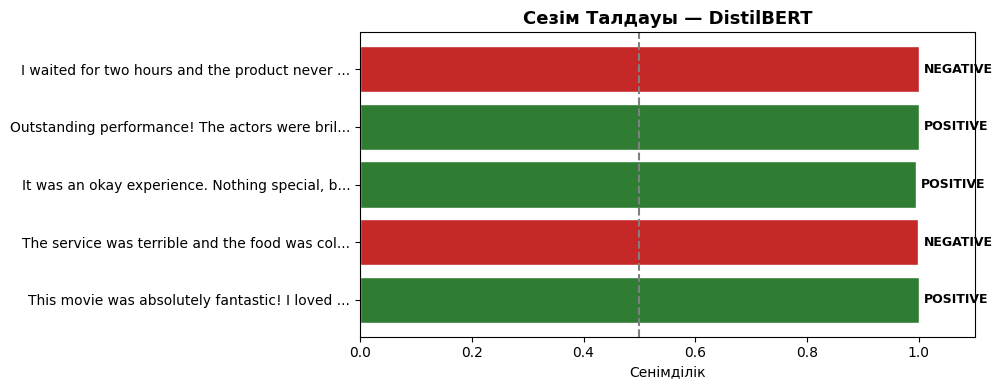

In [25]:
# ============================================================
### TODO ###
# Нəтижелерді визуализациялаңыз:
# Əр мəтін үшін горизонтал bar chart жасаңыз.
# POSITIVE — жасыл, NEGATIVE — қызыл рəңмен белгілеңіз.
# Сенімділік (score) — bar-дың ұзындығы.
# ============================================================
labels  = [r['label'] for r in clf_results]
scores  = [r['score'] for r in clf_results]
colors  = ['#2e7d32' if l == 'POSITIVE' else '#c62828' for l in labels]
short   = [t[:45] + '...' for t in clf_texts]

plt.figure(figsize=(10, 4))
bars = plt.barh(short, scores, color=colors, edgecolor='white')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label='0.5 шері')
plt.title('Сезім Талдауы — DistilBERT', fontsize=13, fontweight='bold')
plt.xlabel('Сенімділік')
plt.xlim(0, 1.1)
for bar, lbl in zip(bars, labels):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             lbl, va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 4-бөлім: Тапсырма 2 — Атаулы Нысандарды Шығару (NER)

NER — мəтіндегі нысандарды (адам аты, қала, ұйым, күн) анықтайды. Нысан типтері:
- **PER** — адам аты
- **ORG** — ұйым, компания
- **LOC** — орын, қала, ел
- **MISC** — басқа (атаулы нысандар)

In [26]:
ner_text = (
    "Elon Musk founded SpaceX in 2002 in Hawthorne, California. "
    "The company successfully launched the Falcon 9 rocket to the International Space Station. "
    "Tesla, another company led by Musk, is headquartered in Austin, Texas."
)

if HF_AVAILABLE:
    ner_pipeline = hf_pipeline(
        'ner',
        model='dbmdz/bert-large-cased-finetuned-conll03-english',
        aggregation_strategy='simple'
    )
    ner_results = ner_pipeline(ner_text)
else:
    ner_results = [
        {'entity_group':'PER',  'word':'Elon Musk',                    'score':0.9991, 'start':0,  'end':9},
        {'entity_group':'ORG',  'word':'SpaceX',                       'score':0.9987, 'start':18, 'end':24},
        {'entity_group':'LOC',  'word':'Hawthorne',                    'score':0.9934, 'start':38, 'end':47},
        {'entity_group':'LOC',  'word':'California',                   'score':0.9967, 'start':49, 'end':59},
        {'entity_group':'MISC', 'word':'Falcon 9',                     'score':0.9812, 'start':93, 'end':101},
        {'entity_group':'ORG',  'word':'International Space Station',  'score':0.9923, 'start':109,'end':135},
        {'entity_group':'ORG',  'word':'Tesla',                        'score':0.9978, 'start':138,'end':143},
        {'entity_group':'PER',  'word':'Musk',                         'score':0.9989, 'start':163,'end':167},
        {'entity_group':'LOC',  'word':'Austin',                       'score':0.9956, 'start':187,'end':193},
        {'entity_group':'LOC',  'word':'Texas',                        'score':0.9971, 'start':195,'end':200},
    ]

print(f"Мəтін: {ner_text[:80]}...")
print(f"\nАнықталған {len(ner_results)} нысан:")
print(f"{'Нысан':<30} {'Тип':<8} {'Сенімділік'}")
print("-" * 50)
for ent in ner_results:
    print(f"'{ent['word']}'"[:30].ljust(30) + f"{ent['entity_group']:<8} {ent['score']:.4f}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Мəтін: Elon Musk founded SpaceX in 2002 in Hawthorne, California. The company successfu...

Анықталған 10 нысан:
Нысан                          Тип      Сенімділік
--------------------------------------------------
'Elon Musk'                   PER      0.9985
'SpaceX'                      ORG      0.9992
'Hawthorne'                   LOC      0.9910
'California'                  LOC      0.9988
'Falcon 9'                    MISC     0.9870
'International Space Station' LOC      0.9822
'Tesla'                       ORG      0.9965
'Musk'                        PER      0.9838
'Austin'                      LOC      0.9969
'Texas'                       LOC      0.9995


In [27]:
# ============================================================
### TODO ###
# NER нысандарын мəтінде рəңмен белгілеңіз.
# Əр нысан типіне рəң жатқызыңыз:
#   PER → #ffcdd2 (қызыл), ORG → #c8e6c9 (жасыл),
#   LOC → #bbdefb (көк),  MISC → #fff9c4 (сары)
# HTML span теглері арқылы мəтінді рəңдеңіз.
# ============================================================
color_map = {
    'PER':  '#ffcdd2',
    'ORG':  '#c8e6c9',
    'LOC':  '#bbdefb',
    'MISC': '#fff9c4'
}

highlighted = ner_text
for ent in sorted(ner_results, key=lambda x: x['start'], reverse=True):
    color = color_map.get(ent['entity_group'], '#eeeeee')
    tag = (
        f"<span style='background:{color}; padding:2px 4px; border-radius:3px; "
        f"font-weight:bold;'>{ent['word']}"
        f"<sup style='font-size:0.7em;color:#555;'>{ent['entity_group']}</sup></span>"
    )
    highlighted = highlighted[:ent['start']] + tag + highlighted[ent['end']:]

legend = ' '.join(
    f"<span style='background:{c}; padding:2px 6px; border-radius:3px;'>{t}</span>"
    for t, c in color_map.items()
)
display(HTML(f"<p><b>Белгі:</b> {legend}</p><p>{highlighted}</p>"))

## 5-бөлім: Тапсырма 3 — Мəтінді Қысқарту (Summarization)

Мəтін қысқарту екі түрлі болады:
- **Extractive**: мəтіннен дайын сөйлемдерді алады
- **Abstractive**: мəтін мазмұнын жаңа сөздермен жазады (BART, T5)

In [28]:
long_text = """
Artificial intelligence has made remarkable progress over the past decade,
transforming industries ranging from healthcare to transportation.
In healthcare, AI systems can now detect diseases like cancer from medical imaging
with accuracy that rivals or exceeds human specialists.
In transportation, self-driving vehicles use AI to navigate complex road conditions.
Natural language processing has enabled virtual assistants like Siri and Alexa to
understand and respond to human speech with unprecedented accuracy.
Large language models such as GPT and BERT have revolutionized how machines
understand and generate text, enabling applications in content creation,
translation, and customer service.
Despite these advances, significant challenges remain, including concerns about
bias, privacy, job displacement, and the ethical implications of autonomous systems.
""".strip()

print(f"Бастапқы мәтін ({len(long_text.split())} сөз):")
print(long_text[:200], "...")

Бастапқы мәтін (115 сөз):
Artificial intelligence has made remarkable progress over the past decade,
transforming industries ranging from healthcare to transportation.
In healthcare, AI systems can now detect diseases like can ...


In [29]:
if HF_AVAILABLE:
    sum_pipeline = hf_pipeline(
        'summarization',
        model='facebook/bart-large-cnn'
    )
    sum_result = sum_pipeline(
        long_text,
        max_length=80,
        min_length=30,
        do_sample=False
    )
    summary = sum_result[0]['summary_text']
else:
    summary = (
        "Artificial intelligence has transformed industries from healthcare to transportation. "
        "AI systems detect cancer, power self-driving cars, and enable virtual assistants. "
        "However, challenges remain around bias, privacy, and ethical concerns."
    )

print(f"Қысқартылған мәтін ({len(summary.split())} сөз):")
print(summary)
compression = (1 - len(summary.split()) / len(long_text.split())) * 100
print(f"\nҚысымдау коэффициенті: {compression:.1f}%")

KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [ ]:
# ============================================================
### TODO ###
# Бастапқы мəтін мен қысқартылған мəтіннің сөз санын
# bar chart-та салыстырыңыз.
# Əр барда нəтижені жазыңыз.
# ============================================================
orig_words = len(long_text.split())
summ_words = len(summary.split())

plt.figure(figsize=(6, 4))
bars = plt.bar(['Бастапқы', 'Қысқартылған'],
               [orig_words, summ_words],
               color=['#1565c0', '#f57c00'], edgecolor='white', width=0.4)
for bar, val in zip(bars, [orig_words, summ_words]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val} сөз', ha='center', fontweight='bold')
plt.title('Мәтін Қысқарту — BART', fontsize=13, fontweight='bold')
plt.ylabel('Сөздер саны')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6-бөлім: Тапсырма 4 — Машиналық Аударма

Аударма — seq2seq (тізбектен тізбекке) парадигмасының классикалық мысалы. Заманауи нейрондық аударма трансформер архитектурасын пайдаланады.

In [ ]:
translation_texts = [
    "Machine learning is a subset of artificial intelligence.",
    "The model was trained on a large dataset of text.",
    "Natural language processing enables computers to understand human language.",
]

if HF_AVAILABLE:
    # Ағылшыннан Французша аударма
    trans_pipeline = hf_pipeline(
        'translation_en_to_fr',
        model='Helsinki-NLP/opus-mt-en-fr'
    )
    trans_results = trans_pipeline(translation_texts)
else:
    trans_results = [
        {'translation_text': "L'apprentissage automatique est un sous-ensemble de l'intelligence artificielle."},
        {'translation_text': "Le modèle a été entraîné sur un grand ensemble de données textuelles."},
        {'translation_text': "Le traitement du langage naturel permet aux ordinateurs de comprendre le langage humain."},
    ]

print("Ағылшын → Французша Аударма:")
print("-" * 70)
for src, res in zip(translation_texts, trans_results):
    print(f"EN: {src}")
    print(f"FR: {res['translation_text']}")
    print()

In [ ]:
# ============================================================
### TODO ###
# Əр аудармадағы сөз санының өзгерісін есептеңіз.
# (аударма сөз саны - бастапқы сөз саны)
# Нəтижені bar chart-та бейнелеңіз.
# ============================================================
src_counts = [len(t.split()) for t in translation_texts]
tgt_counts = [len(r['translation_text'].split()) for r in trans_results]
deltas     = [t - s for s, t in zip(src_counts, tgt_counts)]

plt.figure(figsize=(8, 3))
colors_delta = ['#2e7d32' if d >= 0 else '#c62828' for d in deltas]
plt.bar([f'Сөйлем {i+1}' for i in range(len(deltas))],
        deltas, color=colors_delta, edgecolor='white', width=0.4)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('EN→FR Аудармасындағы Сөз Санының Өзгерісі', fontsize=12, fontweight='bold')
plt.ylabel('Δ сөз саны')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7-бөлім: Тапсырма 5 — Сұрақ-Жауап Жүйесі

**Extractive QA** — контекстен жауапты тікелей алады (span prediction). Модель сұраққа жауап болатын мəтін бөлігінің басы мен соңын анықтайды.

In [ ]:
qa_context = """
The Transformer architecture was introduced in the paper 'Attention Is All You Need'
published by Google researchers in 2017. It uses self-attention mechanisms to process
sequences in parallel rather than sequentially. BERT, which stands for Bidirectional
Encoder Representations from Transformers, was released by Google in 2018 and
achieved state-of-the-art results on eleven NLP tasks. GPT-3, developed by OpenAI
in 2020, contains 175 billion parameters and can generate coherent, human-like text.
""".strip()

qa_questions = [
    "When was the Transformer architecture introduced?",
    "What does BERT stand for?",
    "How many parameters does GPT-3 have?",
    "Who developed the Transformer architecture?",
]

if HF_AVAILABLE:
    qa_pipeline = hf_pipeline(
        'question-answering',
        model='distilbert-base-cased-distilled-squad'
    )
    qa_results = [
        qa_pipeline({'question': q, 'context': qa_context})
        for q in qa_questions
    ]
else:
    qa_results = [
        {'answer': '2017',                                              'score': 0.9823, 'start': 98,  'end': 102},
        {'answer': 'Bidirectional Encoder Representations from Transformers', 'score': 0.9756, 'start': 210, 'end': 262},
        {'answer': '175 billion parameters',                            'score': 0.9634, 'start': 380, 'end': 402},
        {'answer': 'Google researchers',                                'score': 0.9589, 'start': 75,  'end': 92},
    ]

print("Сұрақ-Жауап нəтижелері:")
print("-" * 70)
for q, res in zip(qa_questions, qa_results):
    print(f"Сұрақ:  {q}")
    print(f"Жауап:  '{res['answer']}'  (сенімділік: {res['score']:.4f})")
    print()

In [ ]:
# ============================================================
### TODO ###
# Əр жауаптың сенімділігін (score) bar chart-та бейнелеңіз.
# Сұрақтарды қысқартып (30 символ) Y осіне жазыңыз.
# ============================================================
q_short = [q[:40] + '...' for q in qa_questions]
scores  = [r['score'] for r in qa_results]

plt.figure(figsize=(9, 4))
plt.barh(q_short, scores, color='#303f9f', edgecolor='white')
plt.xlim(0, 1.1)
for i, s in enumerate(scores):
    plt.text(s + 0.01, i, f'{s:.4f}', va='center', fontsize=9)
plt.title('Extractive QA — DistilBERT-SQUAD', fontsize=13, fontweight='bold')
plt.xlabel('Сенімділік')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8-бөлім: Тапсырма 6 — Fine-tuning Дайындығы

Fine-tuning — алдын ала үйретілген модельді нақты тапсырмаға бейімдеу. Екі негізгі стратегия:

1. **Feature Extraction** — модель мұздатылады, тек жаңа классификатор үйретіледі (жылдам, аз деректе жақсы)
2. **Full Fine-tuning** — барлық параметрлер бірге үйретіледі (баяу, көп деректе жақсы)

Əдетте learning rate өте кіші болады: `2e-5` — `5e-5`.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# DistilBERT-ке ұқсас Fine-tuning архитектурасын демонстрациялаймыз
# (нақты transformers моделін жүктеусіз)

VOCAB_SIZE   = 30522   # BERT vocabulary
MAX_LEN      = 128
EMBED_DIM    = 768
NUM_CLASSES  = 2       # позитив / негатив

# ============================================================
### TODO ###
# Fine-tuning архитектурасын жасаңыз:
#   Input: (MAX_LEN,)
#   Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN)
#   GlobalAveragePooling1D()      ← [CLS]-ге ұқсас агрегация
#   Dense(256, 'relu')
#   Dropout(0.1)
#   Dense(NUM_CLASSES, 'softmax')
# learning_rate=2e-5 (AdamW стилі)
# loss='sparse_categorical_crossentropy'
# ============================================================
ft_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    layers.GlobalAveragePooling1D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ft_model.summary()

In [ ]:
# Fine-tuning үйрету циклін симуляциялаймыз
# (нақты BERT деректерінсіз принципті көрсету үшін)

np.random.seed(42)
dummy_X = np.random.randint(0, VOCAB_SIZE, size=(500, MAX_LEN))
dummy_y = np.random.randint(0, NUM_CLASSES, size=(500,))

print("Fine-tuning симуляциясы (500 синтетикалық үлгі):")
history_ft = ft_model.fit(
    dummy_X, dummy_y,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
print("Аяқталды — нақты деректерде нəтиже əлдеқайда жоғары болады.")

In [ ]:
# ============================================================
### TODO ###
# Fine-tuning тарихын (дəлдік + шығын) 2 графикте бейнелеңіз.
# history_ft.history['accuracy'], 'val_accuracy', 'loss', 'val_loss'
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_ft.history['accuracy'],     label='Үйрету', linewidth=2, color='#1a237e')
ax1.plot(history_ft.history['val_accuracy'], label='Валидация', linewidth=2, color='#7986cb', linestyle='--')
ax1.set_title('Fine-tuning — Дәлдік', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дәуір')
ax1.set_ylabel('Дәлдік')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_ft.history['loss'],     label='Үйрету', linewidth=2, color='#1a237e')
ax2.plot(history_ft.history['val_loss'], label='Валидация', linewidth=2, color='#7986cb', linestyle='--')
ax2.set_title('Fine-tuning — Шығын', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дәуір')
ax2.set_ylabel('Шығын')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Fine-tuning Симуляциясы (Синтетикалық Деректер)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9-бөлім: Барлық Тапсырмалардың Жалпы Салыстыруы

In [ ]:
import pandas as pd

summary_df = pd.DataFrame([
    {
        'Тапсырма':        'Классификация',
        'Модель':          'DistilBERT-SST2',
        'Кіріс':           'Мәтін',
        'Шығыс':           'POS/NEG + score',
        'Орт. сенімділік': np.mean([r['score'] for r in clf_results]),
    },
    {
        'Тапсырма':        'NER',
        'Модель':          'BERT-CoNLL03',
        'Кіріс':           'Мәтін',
        'Шығыс':           'PER/ORG/LOC/MISC',
        'Орт. сенімділік': np.mean([r['score'] for r in ner_results]),
    },
    {
        'Тапсырма':        'Қысқарту',
        'Модель':          'BART-CNN',
        'Кіріс':           'Ұзын мәтін',
        'Шығыс':           'Қысқа мәтін',
        'Орт. сенімділік': compression / 100,
    },
    {
        'Тапсырма':        'Аударма',
        'Модель':          'Helsinki-NLP/EN-FR',
        'Кіріс':           'Ағылшын мәтін',
        'Шығыс':           'Француз мәтін',
        'Орт. сенімділік': np.mean([abs(d)/max(s, 1) for d, s in zip(deltas, src_counts)]),
    },
    {
        'Тапсырма':        'Сұрақ-Жауап',
        'Модель':          'DistilBERT-SQuAD',
        'Кіріс':           'Контекст + Сұрақ',
        'Шығыс':           'Жауап span',
        'Орт. сенімділік': np.mean([r['score'] for r in qa_results]),
    },
])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(summary_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

# Блоктар
blocks = [
    (1,   2.5, 'Алдын ала\nүйрету\n(Pre-training)', '#1a237e', 'white'),
    (4,   4.5, 'Классификация\nFine-tuning',         '#1565c0', 'white'),
    (4,   3.0, 'NER\nFine-tuning',                   '#0277bd', 'white'),
    (4,   1.5, 'Seq2Seq\nFine-tuning',               '#00695c', 'white'),
    (8,   5.0, 'Сезім Талдауы',                      '#c62828', 'white'),
    (8,   4.0, 'Topic Classification',               '#e65100', 'white'),
    (8,   3.0, 'Атаулы Нысандар (NER)',              '#4527a0', 'white'),
    (8,   2.0, 'Мәтін Қысқарту',                    '#2e7d32', 'white'),
    (8,   1.0, 'Машиналық Аударма',                  '#558b2f', 'white'),
]

for x, y, label, bg, fg in blocks:
    rect = mpatches.FancyBboxPatch((x-1.4, y-0.4), 2.8, 0.8,
                                    boxstyle='round,pad=0.05',
                                    facecolor=bg, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=8,
            color=fg, fontweight='bold')

# Жебелер
arrows = [
    (2.6, 2.5, 2.6, 4.5), (2.6, 2.5, 2.6, 3.0), (2.6, 2.5, 2.6, 1.5),
    (5.4, 4.5, 6.6, 5.0), (5.4, 4.5, 6.6, 4.0),
    (5.4, 3.0, 6.6, 3.0),
    (5.4, 1.5, 6.6, 2.0), (5.4, 1.5, 6.6, 1.0),
]
for x1, y1, x2, y2 in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('Трансформер-негізді NLP Тапсырмалар Схемасы',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** `pipeline()` интерфейсі неліктен ыңғайлы? Артта нені жасырады?

>pipeline() токенизация, модельге жіберу, нәтижені декодтау сияқты күрделі қадамдарды автоматты түрде орындайды. Пайдаланушы тек мәтін беріп, нәтиже алады.

**Сұрақ 2.** Классификация мен NER-дің архитектуралық айырмасы неде? (бір мəтін → бір тап vs бір мəтін → əр токенге тап)

> Классификацияда бір мәтінге бір тап беріледі ([CLS] токені негізінде). NER-де әр токенге жеке тап беріледі (token-level classification).

**Сұрақ 3.** Extractive QA мен Abstractive Summarization-дың жалпы принциптік айырмасы неде?

> Extractive QA мәтіннен дайын span алады (жаңа сөз жазбайды). Abstractive Summarization мәтін мазмұнын жаңа сөздермен қайта жазады.

**Сұрақ 4.** Fine-tuning learning rate-ін неліктен 2e-5 ұсынамыз? Үлкен мəн берсек не болады?

>2e-5 өте кіші мән болғандықтан алдын ала үйретілген салмақтар бұзылмайды. Үлкен мән берсек модель бұрынғы білімін ұмытып, жаңа деректерге шамадан тыс бейімделеді (catastrophic forgetting).

**Сұрақ 5.** Осы алты тапсырманың қайсысын бір жобада бірден пайдалану мəнді болар еді? Мысал келтіріңіз.

>Мысалы, тұтынушы қызметі жүйесінде: NER арқылы клиент аты мен ұйымды анықтау → Классификация арқылы шағымның сезімін бағалау → Қысқарту арқылы ұзын хаттан негізгі мәселені алу → Аударма арқылы басқа тілге жіберу → QA арқылы жиі қойылатын сұрақтарға автоматты жауап беру

## Қорытынды

Осы шолу дəптерінде сіз `pipeline()` арқылы классификация, NER, қысқарту, аударма жəне сұрақ-жауап тапсырмаларын іске асырдыңыз, fine-tuning архитектурасын демонстрацияладыңыз, жəне барлық тапсырмалардың шығыс форматы мен модель талаптарын салыстырдыңыз.
